In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import pandas as pd
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import time 
import torch.nn.functional as F
import math
# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set default tensor type to float32
torch.set_default_tensor_type(torch.FloatTensor)

Using device: cuda


/venv/main/lib/python3.12/site-packages/torch/__init__.py:1305: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


# ANN

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(2, 80) # Input layer to first hidden layer
        self.hidden2 = nn.Linear(80, 80)
        self.hidden3 = nn.Linear(80, 80)
        self.hidden4 = nn.Linear(80, 80)
        self.hidden5 = nn.Linear(80, 80)
        self.output = nn.Linear(80, 6) # 6 output classes
    
    def forward(self, x):
        x = torch.tanh(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        x = torch.tanh(self.hidden3(x))
        x = torch.tanh(self.hidden4(x))
        x = torch.tanh(self.hidden5(x))
        return self.output(x)

# Vertice

In [3]:
vertices = np.array([
    [0, 0],
    [0, 4],
    [5, 4],
    [5, 0],
    [0, 0],
], dtype=np.float32)
path = Path(vertices)

def in_domain(x, y):
    points = np.column_stack((x.cpu().numpy(), y.cpu().numpy()))
    return torch.tensor(path.contains_points(points), dtype=torch.bool, device=device)

# Load Data

📊 FEM DATA LOADING WITH ADAPTIVE PROBABILISTIC SAMPLING
✓ Successfully loaded 'Von_mises.csv'

🎯 Computing Adaptive Weights...
✓ Sampled 1,272 points using Probability Distribution
  (Density Alpha: 1.5)


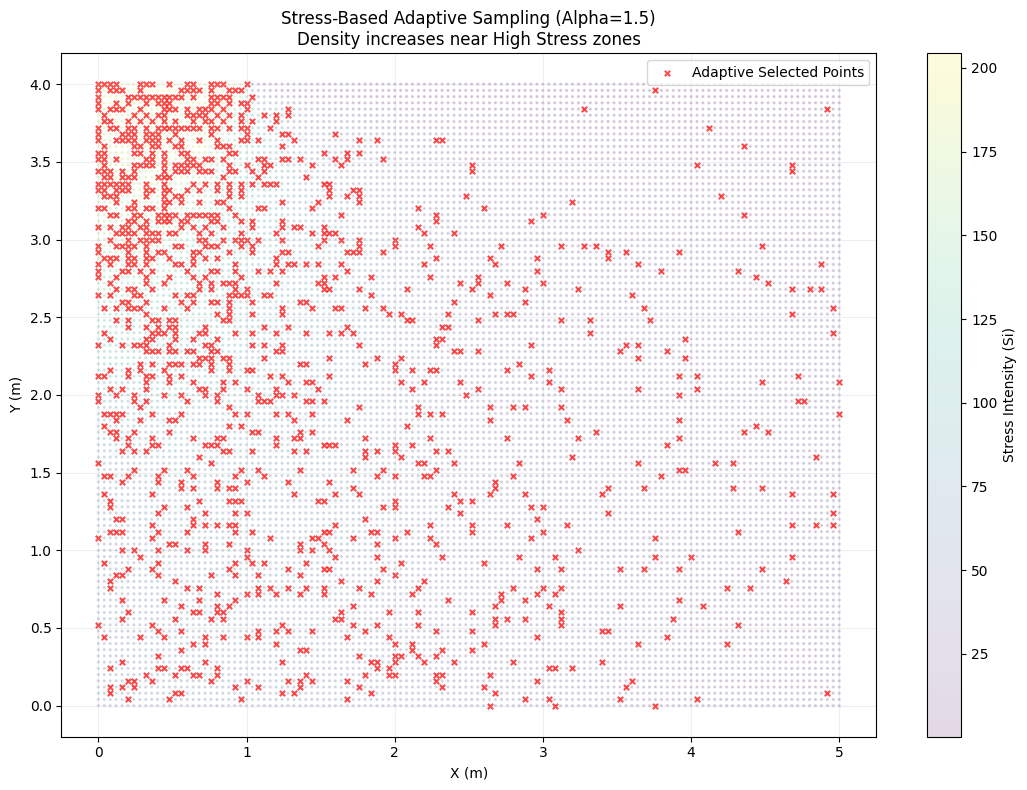


📋 Summary:
  - Total Data Points: 12,726
  - Selected Points:   1,272 (10.0%)


In [4]:
# ========================================
# Load FEM Data with STRAIN-BASED ADAPTIVE PROBABILISTIC SAMPLING
# ========================================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# ========================================
# CONFIGURATION
# ========================================
sample_ratio = 0.10  
alpha = 1.5          
min_prob = 1e-4  

print("="*70)
print(f"📊 FEM DATA LOADING WITH ADAPTIVE PROBABILISTIC SAMPLING")
print("="*70)

# Load FEM data
try:
    fem_data = pd.read_csv('Von_mises.csv')
    print(f"✓ Successfully loaded 'Von_mises.csv'")
except FileNotFoundError:
    print(f"✗ Error: 'Von_mises.csv' not found!")
    raise

total_points = len(fem_data)
n_sample = max(1, int(total_points * sample_ratio))

# ========================================
# 🎯 ADAPTIVE WEIGHT COMPUTATION
# ========================================
print("\n🎯 Computing Adaptive Weights...")

# 1. Extract strain components
stress_xx = fem_data['Stress_xx'].values  # ใช้ Stress แทน strain
stress_yy = fem_data['Stress_yy'].values
stress_zz = fem_data['Stress_zz'].values
stress_xy = fem_data['Stress_xy'].values

# 2. Calculate Strain Intensity (Si)
Si = np.sqrt(stress_xx**2 + stress_yy**2 + stress_zz**2 + 2*stress_xy**2)

# 3. Normalize Si in range [0, 1]
Si_min, Si_max = Si.min(), Si.max()
Si_norm = (Si - Si_min) / (Si_max - Si_min + 1e-8)

# 4.Probability Weights (Importance Sampling)
weights = (Si_norm ** alpha) + min_prob 

# 5. Normalize 1 (Probability Distribution)
weights /= weights.sum()

# 6. (Weighted Random Sampling)
np.random.seed(42)
sampled_indices = np.random.choice(
    total_points, 
    size=n_sample, 
    replace=False, 
    p=weights
)

# สร้าง sampled dataframe
fem_data_sampled = fem_data.iloc[sampled_indices].reset_index(drop=True)

print(f"✓ Sampled {len(fem_data_sampled):,} points using Probability Distribution")
print(f"  (Density Alpha: {alpha})")

# ==========================================
# EXTRACT TO TORCH TENSORS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Coordinates
fem_x = torch.tensor(fem_data_sampled['X'].values, dtype=torch.float32).reshape(-1, 1).to(device)
fem_y = torch.tensor(fem_data_sampled['Y'].values, dtype=torch.float32).reshape(-1, 1).to(device)
fem_xy = torch.cat([fem_x, fem_y], dim=1)

# Target Values (Displacements, Stresses, Strains)
fem_ux = torch.tensor(fem_data_sampled['ux'].values, dtype=torch.float32).reshape(-1, 1).to(device)
fem_uy = torch.tensor(fem_data_sampled['uy'].values, dtype=torch.float32).reshape(-1, 1).to(device)

# Stresses (Converted to kPa)
fem_stress_xx = torch.tensor(fem_data_sampled['Stress_xx'].values/1000, dtype=torch.float32).reshape(-1, 1).to(device)
fem_stress_yy = torch.tensor(fem_data_sampled['Stress_yy'].values/1000, dtype=torch.float32).reshape(-1, 1).to(device)
fem_stress_zz = torch.tensor(fem_data_sampled['Stress_zz'].values/1000, dtype=torch.float32).reshape(-1, 1).to(device)
fem_stress_xy = torch.tensor(fem_data_sampled['Stress_xy'].values/1000, dtype=torch.float32).reshape(-1, 1).to(device)

# Strains
fem_strain_xx = torch.tensor(fem_data_sampled['strain_xx'].values, dtype=torch.float32).reshape(-1, 1).to(device)
fem_strain_yy = torch.tensor(fem_data_sampled['strain_yy'].values, dtype=torch.float32).reshape(-1, 1).to(device)
fem_strain_xy = torch.tensor(fem_data_sampled['strain_xy'].values, dtype=torch.float32).reshape(-1, 1).to(device)

# ==========================================
# 📊 VISUALIZATION
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(11, 8))


sc = ax.scatter(fem_data['X'], fem_data['Y'], c=Si, cmap='viridis', s=2, alpha=0.15)


ax.scatter(fem_data_sampled['X'], fem_data_sampled['Y'], 
           c='red', s=15, marker='x', label='Adaptive Selected Points', alpha=0.7)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'Stress-Based Adaptive Sampling (Alpha={alpha})\nDensity increases near High Stress zones')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Stress Intensity (Si)')

plt.tight_layout()
plt.show()

print("\n📋 Summary:")
print(f"  - Total Data Points: {total_points:,}")
print(f"  - Selected Points:   {len(fem_data_sampled):,} ({sample_ratio*100:.1f}%)")

# BC

In [5]:
def BC_bottom(x, y):
    tol = 1e-6
    return ((torch.abs(y - 0) < tol) & (x >= 0) & (x <= 5)).squeeze()

def BC_left(x, y):
    tol = 1e-6
    return ((torch.abs(x - 0) < tol) & (y >= 0) & (y <= 4)).squeeze()

def BC_top(x, y):
    tol = 1e-6
    return ((torch.abs(y - 4) < tol) & (x >= 0) & (x <= 5)).squeeze()

def BC_right(x, y):
    tol = 1e-6
    return ((torch.abs(x - 5) < tol) & (y >= 0) & (y <= 4)).squeeze()

# Material Parameters

In [6]:

# Elastic parameters
E = 15.0     # Young's modulus (MPa)
nu = 0.3         # Poisson's ratio

# Plastic parameter
sigma_y = 0.07   # Yield stress (MPa)

print("="*50)
print("Material Parameters:")
print("="*50)
print(f"Young's Modulus (E):     {E:.2f} MPa")
print(f"Poisson's Ratio (ν):     {nu:.3f}")
print(f"Yield Stress (σ_Y):      {sigma_y:.2f} MPa")
print("="*50)

# Convert to tensors
sigma_Y_tensor = torch.tensor(sigma_y, dtype=torch.float32, device=device)

Material Parameters:
Young's Modulus (E):     15.00 MPa
Poisson's Ratio (ν):     0.300
Yield Stress (σ_Y):      0.07 MPa


# BC Loss

In [7]:
def BC(xy, net):
    """Boundary Conditions (No initial stress)"""
    x, y = xy[:, 0].unsqueeze(1), xy[:, 1].unsqueeze(1)
    
    output = net(xy)
    u = output[:, 0:1]
    v = output[:, 1:2]
    sigma_xx = output[:, 2:3]
    sigma_yy = output[:, 3:4]
    sigma_xy = output[:, 4:5]
    
    # Identify boundaries
    bc_b = BC_bottom(x, y)
    bc_l = BC_left(x, y)
    bc_t = BC_top(x, y)
    bc_r = BC_right(x, y)
    
    loss = 0.0
    
    # Bottom BC: u=0, v=0
    loss += F.mse_loss(u[bc_b], torch.zeros_like(u[bc_b]))
    loss += F.mse_loss(v[bc_b], torch.zeros_like(v[bc_b]))
    
    # Left BC: u=0, σ_xy=0
    loss += F.mse_loss(u[bc_l], torch.zeros_like(u[bc_l]))
    loss += F.mse_loss(sigma_xy[bc_l], torch.zeros_like(sigma_xy[bc_l]))
    
    # Right BC: u=0, σ_xy=0
    loss += F.mse_loss(u[bc_r], torch.zeros_like(u[bc_r]))
    loss += F.mse_loss(sigma_xy[bc_r], torch.zeros_like(sigma_xy[bc_r]))
    
    # Top BC
    x_top = x[bc_t]
    sigma_yy_top = sigma_yy[bc_t]
    sigma_xy_top = sigma_xy[bc_t]
    
    loss += F.mse_loss(sigma_xy_top, torch.zeros_like(sigma_xy_top))
    
    load_mask = (x_top >= 0) & (x_top <=1)
    load_mask = load_mask.squeeze()
    no_load_mask = ~load_mask
    
    if torch.any(no_load_mask):
        loss += F.mse_loss(sigma_yy_top[no_load_mask], torch.zeros_like(sigma_yy_top[no_load_mask]))
    
    if torch.any(load_mask):
        loss += F.mse_loss(sigma_yy_top[load_mask], -0.120 * torch.ones_like(sigma_yy_top[load_mask]))
    
    return loss

# Data loss

In [8]:
def data_loss(net, fem_xy, fem_ux, fem_uy, 
              fem_stress_xx, fem_stress_yy, fem_stress_xy, fem_stress_zz,
              fem_strain_xx, fem_strain_yy, fem_strain_xy):

    device = next(net.parameters()).device
    
    # --- 1. Displacement Loss ---
    if fem_xy is not None and len(fem_xy) > 0:
        output_disp = net(fem_xy)
        u_pred = output_disp[:, 0:1]
        v_pred = output_disp[:, 1:2]
        
        loss_u = F.mse_loss(u_pred, fem_ux)
        loss_v = F.mse_loss(v_pred, fem_uy)
    else:
        loss_u = torch.tensor(0.0, device=device)
        loss_v = torch.tensor(0.0, device=device)

    # --- 2. Stress Loss ---
    if fem_xy is not None and len(fem_xy) > 0:
        output_stress = net(fem_xy)
        s_xx_pred = output_stress[:, 2:3]
        s_yy_pred = output_stress[:, 3:4]
        s_xy_pred = output_stress[:, 4:5]
        s_zz_pred = output_stress[:, 5:6]
        
        loss_s_xx = F.mse_loss(s_xx_pred, fem_stress_xx)
        loss_s_yy = F.mse_loss(s_yy_pred, fem_stress_yy)
        loss_s_xy = F.mse_loss(s_xy_pred, fem_stress_xy)
        loss_s_zz = F.mse_loss(s_zz_pred, fem_stress_zz)
    else:
        loss_s_xx = torch.tensor(0.0, device=device)
        loss_s_yy = torch.tensor(0.0, device=device)
        loss_s_xy = torch.tensor(0.0, device=device)
        loss_s_zz = torch.tensor(0.0, device=device)
    
    # --- 3. Strain Loss ---
    loss_e_xx = torch.tensor(0.0, device=device)
    loss_e_yy = torch.tensor(0.0, device=device)
    loss_e_xy = torch.tensor(0.0, device=device)
    
    epsilon_xx_pred = None
    epsilon_yy_pred = None
    gamma_xy_pred = None
    
    if fem_xy is not None and len(fem_xy) > 0:
        # Calculate strain from displacement gradients
        fem_xy_grad = fem_xy.detach().requires_grad_(True)
        output_strain = net(fem_xy_grad)
        u_strain = output_strain[:, 0:1]
        v_strain = output_strain[:, 1:2]
        
        # Calculate gradients
        u_x = torch.autograd.grad(u_strain.sum(), fem_xy_grad, 
                                  create_graph=True, retain_graph=True)[0][:, 0:1]
        u_y = torch.autograd.grad(u_strain.sum(), fem_xy_grad, 
                                  create_graph=True, retain_graph=True)[0][:, 1:2]
        v_x = torch.autograd.grad(v_strain.sum(), fem_xy_grad, 
                                  create_graph=True, retain_graph=True)[0][:, 0:1]
        v_y = torch.autograd.grad(v_strain.sum(), fem_xy_grad, 
                                  create_graph=True, retain_graph=True)[0][:, 1:2]
        
        # Strain components
        epsilon_xx_pred = u_x
        epsilon_yy_pred = v_y
        gamma_xy_pred = u_y + v_x  # Engineering strain
        
        # MSE loss
        loss_e_xx = F.mse_loss(epsilon_xx_pred, fem_strain_xx)
        loss_e_yy = F.mse_loss(epsilon_yy_pred, fem_strain_yy)
        loss_e_xy = F.mse_loss(gamma_xy_pred, fem_strain_xy)
    
    # --- 4. Total Data Loss ---
    total_data_loss = (loss_u + loss_v + 
                       loss_s_xx + loss_s_yy + loss_s_xy + loss_s_zz +
                       loss_e_xx + loss_e_yy + loss_e_xy)
    
    # Return both loss and strain components
    return total_data_loss, epsilon_xx_pred, epsilon_yy_pred, gamma_xy_pred

# Elasticity

In [9]:
import torch
import numpy as np
import torch.nn.functional as F

def get_lame_parameters(E, nu, device='cuda', dtype=torch.float32):
    """
    Calculate Lamé parameters
    λ = E*ν / ((1+ν)(1-2ν))  # Lamé's first parameter
    μ = E / (2(1+ν))         # Shear modulus (Lamé's second parameter)
    """
    if not isinstance(E, torch.Tensor):
        E = torch.tensor(E, dtype=dtype, device=device)
    if not isinstance(nu, torch.Tensor):
        nu = torch.tensor(nu, dtype=dtype, device=device)
    
    lambda_lame = E * nu / ((1 + nu) * (1 - 2*nu))
    mu = E / (2 * (1 + nu))
    
    return lambda_lame,mu 

def get_elasticity_matrices(E, nu, device='cuda', dtype=torch.float32):
    """
    ✅ CORRECTED: Autograd-safe version
    """
    # Ensure inputs are tensors
    if not isinstance(E, torch.Tensor):
        E = torch.tensor(E, dtype=dtype, device=device)
    if not isinstance(nu, torch.Tensor):
        nu = torch.tensor(nu, dtype=dtype, device=device)
    
    # Get Lamé parameters
    lambda_lame, mu = get_lame_parameters(E, nu, device, dtype)
    
    
    zero = torch.tensor(0.0, device=device, dtype=dtype)

    # --- Elasticity matrix (stiffness) [C] 4x4 ---
    # torch.stack แทน torch.tensor 
    # Row 1: [λ+2μ, λ, λ, 0]
    r1 = torch.stack([lambda_lame + 2*mu, lambda_lame, lambda_lame, zero])
    # Row 2: [λ, λ+2μ, λ, 0]
    r2 = torch.stack([lambda_lame, lambda_lame + 2*mu, lambda_lame, zero])
    # Row 3: [λ, λ, λ+2μ, 0]
    r3 = torch.stack([lambda_lame, lambda_lame, lambda_lame + 2*mu, zero])
    # Row 4: [0, 0, 0, 2μ]
    r4 = torch.stack([zero, zero, zero, 2*mu])
    
    C = torch.stack([r1, r2, r3, r4])

    # --- Compliance matrix [S] 4x4 ---
    # Row 1
    s1 = torch.stack([1.0/E, -nu/E, -nu/E, zero])
    # Row 2
    s2 = torch.stack([-nu/E, 1.0/E, -nu/E, zero])
    # Row 3
    s3 = torch.stack([-nu/E, -nu/E, 1.0/E, zero])
    # Row 4
    s4 = torch.stack([zero, zero, zero, 1.0/(2*mu)])
    
    S = torch.stack([s1, s2, s3, s4])

    return C, S

# Stress Invariant

In [10]:
def calculate_stress_invariants(sigma_xx, sigma_yy, sigma_zz, sigma_xy):
    """
    Calculate stress invariants: I1, J2, J3
    Compatible with autodiff
    """
    # First invariant
    I1 = sigma_xx + sigma_yy + sigma_zz
    
    # Mean stress
    s_mean = I1 / 3.0
    
    # Deviatoric stress
    s_xx = sigma_xx - s_mean
    s_yy = sigma_yy - s_mean
    s_zz = sigma_zz - s_mean
    s_xy = sigma_xy
    
    # Second invariant J2
    J2 = 0.5 * (s_xx**2 + s_yy**2 + s_zz**2) + s_xy**2
    J2 = torch.clamp(J2, min=1e-10)
    
    
    return J2

# Yield Function

In [11]:
def yield_function(J2, sigma_y):
    """
    Von Mises Yield Function
    F = sqrt(3*J2) - sigma_y
    
    Args:
        I1: First invariant (Unused in Von Mises but kept for API compatibility)
        J2: Second invariant of deviatoric stress
        theta: Lode angle (Unused in Von Mises)
        sigma_y: Yield strength (Replaces c and phi)
    """
    # 1. Setup device & type
    device = J2.device
    dtype = J2.dtype
    
    # 2. Calculate Von Mises Stress (q)
    # q = sqrt(3 * J2)
    sqrt_3 = torch.sqrt(torch.tensor(3.0, device=device, dtype=dtype))
    
    # Safe sqrt for J2 to avoid NaN gradients
    sqrt_J2 = torch.sqrt(torch.clamp(J2, min=1e-12))
    
    von_mises_stress = sqrt_3 * sqrt_J2
    
    # 3. Handle sigma_y (ensure it's a tensor)
    if not isinstance(sigma_y, torch.Tensor):
        sigma_y = torch.tensor(sigma_y, device=device, dtype=dtype)
        
    # 4. Calculate Yield Function F
    # F <= 0 : Elastic
    # F > 0  : Plastic
    F = von_mises_stress - sigma_y
    
    return F

# Plastic Potential Function

In [12]:
def plastic_potential_function(J2, sigma_y):
    """
    Plastic potential function Q for Von Mises (Associated Flow)
    
    For Von Mises: Q = F = sqrt(3*J2) - sigma_y
    (Note: The constant sigma_y doesn't affect the gradient/flow direction, 
           but we keep it for consistency with Q=F)
    """
    # 1. Setup device & type
    device = J2.device
    dtype = J2.dtype
    
    # 2. Von Mises doesn't depend on Lode angle (theta) or Dilation angle (psi)
    #    It depends ONLY on J2.
    
    sqrt_3 = torch.sqrt(torch.tensor(3.0, device=device, dtype=dtype))
    
    # Safe sqrt for J2
    sqrt_J2 = torch.sqrt(torch.clamp(J2, min=1e-12))
    
    # 3. Calculate Q
    # Q = sqrt(3 * J2) - sigma_y
    # Note: When we take derivative dQ/dsigma, the sigma_y term disappears.
    
    if not isinstance(sigma_y, torch.Tensor):
        sigma_y = torch.tensor(sigma_y, device=device, dtype=dtype)
        
    Q = sqrt_3 * sqrt_J2 - sigma_y
    
    return Q

# Flow vector autodiff

In [ ]:
def get_flow_vector_autodiff(sigma_voigt_4x1, sigma_y):

    # --- 1. Shape Handling
    original_shape = sigma_voigt_4x1.shape
    is_batched = sigma_voigt_4x1.dim() > 1
    
    if not is_batched:
        sigma = sigma_voigt_4x1.unsqueeze(0)
    else:
        sigma = sigma_voigt_4x1
    
    # Enable grad if needed
    if not sigma.requires_grad:
        sigma = sigma.requires_grad_(True)
    
    # --- 2. Calculate Invariants
    J2 = calculate_stress_invariants(
        sigma[..., 0], sigma[..., 1], 
        sigma[..., 2], sigma[..., 3]
    )
    
    
    # --- 3. Calculate Potential/Yield ---
    # ✅ KEY CHANGE: Von Mises is Associated Flow (Q = F)
    Q = yield_function(J2, sigma_y)

    # --- 4. Autograd ---
    dQ_dsigma = torch.autograd.grad(
        outputs=Q,
        inputs=sigma,
        grad_outputs=torch.ones_like(Q),
        create_graph=True,
        retain_graph=True,
        allow_unused=False
    )[0]
    
    # Restore original shape
    if not is_batched:
        dQ_dsigma = dQ_dsigma.squeeze(0)
    
    return dQ_dsigma

# Plastic multiplier

In [ ]:
import torch

def plastic_multiplier_autodiff(sigma_voigt_4x1, sigma_y, C_matrix, deps_voigt_4x1):
    epsilon = 1e-12
    
    # 1. Shape Handling
    is_batched = sigma_voigt_4x1.dim() > 1
    if not is_batched:
        sigma = sigma_voigt_4x1.unsqueeze(0)
        deps = deps_voigt_4x1.unsqueeze(0)
    else:
        sigma = sigma_voigt_4x1
        deps = deps_voigt_4x1

    # 2. Get Flow Vector n
    n_vec = get_flow_vector_autodiff(sigma, sigma_y)
    
    # =========================================================
    # 🚩 2.5 SMOOTH GATING WITH CUTOFF
    # =========================================================
    s_xx, s_yy, s_zz, s_xy = sigma[:, 0], sigma[:, 1], sigma[:, 2], sigma[:, 3]
    sigma_m = (s_xx + s_yy + s_zz) / 3.0
    s_xx_dev = s_xx - sigma_m
    s_yy_dev = s_yy - sigma_m
    s_zz_dev = s_zz - sigma_m
    s_xy_dev = s_xy 
    J2 = 0.5 * (s_xx_dev**2 + s_yy_dev**2 + s_zz_dev**2) + (s_xy_dev**2)
    sigma_vm = torch.sqrt(3.0 * J2 + epsilon)
    
    # คำนวณ Yield Function
    F_val = sigma_vm - sigma_y
    
    # Normalization
    F_normalized = F_val / (sigma_y + epsilon)
    
    # --- STEP A: Smooth Transition ---
    # alpha = 50
    alpha = 20 
    raw_gate = torch.sigmoid(alpha * F_normalized).view(-1, 1)
    
    # --- STEP B: Clean Cutoff ---
    cutoff = 0.1 
    clean_gate = torch.relu(raw_gate - cutoff)
    
    # --- STEP C: Rescale ---
    #(x - cutoff) / (1 - cutoff)
    is_yielding = clean_gate / (1.0 - cutoff)
    
    # =========================================================

    # 3. Calculate Numerator & Denominator (Consistency Condition)
    C_deps = torch.matmul(deps, C_matrix.t()) 
    C_n = torch.matmul(n_vec, C_matrix.t())
    
    numerator = torch.sum(n_vec * C_deps, dim=1)      
    denominator = torch.sum(n_vec * C_n, dim=1)       
    
    # 4. Calculate Lambda
    denominator = torch.clamp(denominator, min=epsilon)
    d_lambda = numerator / denominator
    
    #
    d_lambda = torch.relu(d_lambda)
    
    # 🚩 Apply The Perfect Gate
    #(Smooth but Clean)
    d_lambda = d_lambda * is_yielding.squeeze(-1)
    
    # 5. Restore Shape
    if not is_batched:
        d_lambda = d_lambda.squeeze(0)
        n_vec = n_vec.squeeze(0)
        
    return d_lambda, n_vec

# Stress increment autodiff

In [ ]:
def stress_increment_autodiff(sigma_voigt_4x1, sigma_y, C_matrix, deps_voigt_4x1, d_lambda):
    """
    ✅ VON MISES: Calculate stress increment
    
    Formula:
    dσ = C : (dε - dεᵖ)
    dσ = C : (dε - λₚ * n)
    
    Args:
        sigma_voigt_4x1: Current stress [Batch, 4]
        sigma_y: Yield strength
        C_matrix: Elasticity Matrix [4, 4] (Must be the Tensor one with 2*mu)
        deps_voigt_4x1: Total Strain Increment [Batch, 4] (Must be Tensor Strain!)
        d_lambda: Plastic multiplier
    """
    # 1. Shape Handling
    is_batched = sigma_voigt_4x1.dim() > 1
    if not is_batched:
        sigma = sigma_voigt_4x1.unsqueeze(0)
        deps = deps_voigt_4x1.unsqueeze(0)
        d_lambda = d_lambda.unsqueeze(0) if d_lambda.dim() == 0 else d_lambda
    else:
        sigma = sigma_voigt_4x1
        deps = deps_voigt_4x1
        # Make sure lambda matches batch [B, 1]
        if d_lambda.dim() == 1:
            d_lambda = d_lambda.unsqueeze(-1)
            
    # 2. Get Flow Vector n (Normal to Yield Surface)
    # Von Mises: Associated Flow (n = m)
    n_vec = get_flow_vector_autodiff(sigma, sigma_y)
    
    # 3. Calculate Elastic Strain Increment (dεᵉ)
    # dεᵉ = dε - dεᵖ
    # dεᵖ = λₚ * n
    
    # deps_plastic = d_lambda * n_vec
    deps_plastic = d_lambda * n_vec
    
    # deps_elastic = Total - Plastic
    deps_elastic = deps - deps_plastic
    
    # 4. Calculate Stress Increment (dσ) using Matrix Multiplication
    # dσ = C * dεᵉ
    # matmul2*mu
    
    # [Batch, 4] = [Batch, 4] @ [4, 4]^T
    dsigma_voigt = torch.matmul(deps_elastic, C_matrix.t())
    
    # 5. Restore Shape
    if not is_batched:
        dsigma_voigt = dsigma_voigt.squeeze(0)
        
    return dsigma_voigt

# Tangent Sitffness

In [ ]:
def calculate_consistent_tangent_autodiff(sigma_voigt_4x1, sigma_y, C_matrix, d_lambda):
    """
    ✅ VON MISES: Elastoplastic tangent stiffness (Associated Flow)
    
    C^ep = C - (C·n ⊗ n·C) / (n·C·n)
    
    Since n (normal) is symmetric for Von Mises, the result is SYMMETRIC.
    """
    epsilon = 1e-12
    
    # 1. Shape Handling
    is_batched = sigma_voigt_4x1.dim() > 1
    if not is_batched:
        sigma = sigma_voigt_4x1.unsqueeze(0)
        d_lambda_in = d_lambda.unsqueeze(0) if d_lambda.dim() == 0 else d_lambda
    else:
        sigma = sigma_voigt_4x1
        d_lambda_in = d_lambda

    batch_size = sigma.shape[0]
    
    # 2. Elastic Check
    if torch.all(d_lambda_in < epsilon):
        C_expanded = C_matrix.unsqueeze(0).expand(batch_size, -1, -1)
        if not is_batched:
            return C_expanded.squeeze(0)
        return C_expanded

    # 3. Calculate Flow Vector n (Normal)
    # Von Mises: Associated Flow -> n = ∂F/∂σ = ∂Q/∂σ
    n_vec = get_flow_vector_autodiff(sigma, sigma_y)
    
    if n_vec.dim() == 1:
        n_vec = n_vec.unsqueeze(0)
        
    # 4. Matrix Operations (Vectorized)
    # Term: v = C · n
    # C [4,4], n [B,4] -> v [B,4]
    v_vec = torch.matmul(n_vec, C_matrix.t())
    
    # Denominator: n · C · n  => n · v
    # [B,4] dot [B,4] -> [B, 1, 1]
    denominator = torch.sum(n_vec * v_vec, dim=-1, keepdim=True).unsqueeze(-1)
    denominator = torch.clamp(denominator, min=epsilon)
    
    # Numerator: (C·n) ⊗ (C·n)^T => v ⊗ v^T
    # [B, 4, 1] x [B, 1, 4] -> [B, 4, 4]
    numerator = torch.matmul(
        v_vec.unsqueeze(-1),
        v_vec.unsqueeze(-2)
    )
    
    # 5. Calculate Cep
    # C_ep = C - Numerator / Denominator
    C_expanded = C_matrix.unsqueeze(0).expand(batch_size, -1, -1)
    
    # เฉพาะจุดที่มี Plastic Flow (d_lambda > 0) เท่านั้นที่จะถูกลบออก
    # สร้าง Mask เพื่อความชัวร์ (Optional แต่แนะนำ)
    is_plastic = (d_lambda_in > epsilon).float().view(-1, 1, 1)
    
    D_ep = C_expanded - is_plastic * (numerator / denominator)
    
    # 6. Restore Shape
    if not is_batched:
        D_ep = D_ep.squeeze(0)
        
    return D_ep

# Elastoplastic stiffness autodiff

In [ ]:
def calculate_Cep_elastoplastic_stiffness_autodiff(sigma_voigt_4x1, sigma_y, C_matrix):

    epsilon = 1e-12
    
    # 1. Shape Handling (Standardize to [Batch, 4])
    is_batched = sigma_voigt_4x1.dim() > 1
    if not is_batched:
        sigma = sigma_voigt_4x1.unsqueeze(0)
    else:
        sigma = sigma_voigt_4x1
        
    batch_size = sigma.shape[0]

    # 2. Check Yield State (Elastic vs Plastic)
    J2 = calculate_stress_invariants(
        sigma[:, 0], sigma[:, 1], 
        sigma[:, 2], sigma[:, 3]
    )
    
    #F (Von Mises)
    # F = sqrt(3*J2) - sigma_y
    F = yield_function(J2, sigma_y)
    
    # --- Optimization: Early Exit ---
    if torch.all(F < -epsilon):
        C_expanded = C_matrix.unsqueeze(0).expand(batch_size, -1, -1)
        if not is_batched:
            return C_expanded.squeeze(0)
        return C_expanded
    
    # 3. Calculate Flow Vector n (Normal)
    n_vec = get_flow_vector_autodiff(sigma, sigma_y) # [Batch, 4]
    
    # 4. Calculate Cep Terms
    # Term: v = C · n
    # C [4,4], n [B,4] -> v [B,4]
    v_vec = torch.matmul(n_vec, C_matrix) 
    
    # Denominator: n · C · n  => n · v
    dF_C_dF = torch.sum(n_vec * v_vec, dim=-1, keepdim=True).unsqueeze(-1) # [B, 1, 1]
    dF_C_dF = torch.clamp(dF_C_dF, min=epsilon)
    
    # Numerator: (C·n) ⊗ (C·n)^T => v ⊗ v^T (Outer Product)
    # torch.bmm: [B, 4, 1] x [B, 1, 4] -> [B, 4, 4]
    outer_product = torch.bmm(
        v_vec.unsqueeze(-1),
        v_vec.unsqueeze(-2)
    )
    
    # 5. Assemble C^ep
    C_expanded = C_matrix.unsqueeze(0).expand(batch_size, -1, -1)
    Cep = C_expanded - outer_product / dF_C_dF
    
    # 6. Apply Mask (Mix Elastic/Plastic)
    # Elastic (F < 0)
    # Plastic (F >= 0)
    elastic_mask = (F < -epsilon).view(-1, 1, 1).expand(-1, 4, 4)
    Cep = torch.where(elastic_mask, C_expanded, Cep)
    
    # Restore Shape
    if not is_batched:
        Cep = Cep.squeeze(0)
    
    return Cep

# KKT Loss

In [ ]:
def calculate_KKT_loss(d_sigma_xx, d_sigma_yy, d_sigma_zz, d_sigma_xy,  # ← Increments
                       d_epsilon_xx, d_epsilon_yy, d_gamma_xy,           # ← Increments (Eng. Shear)
                       sigma_initial,  # ← Initial stress
                       sigma_y,        # ← NEW: Yield Strength (Von Mises)
                       E, nu, device):
    """
    ✅ VON MISES: KKT Loss
    
    Changes:
    1. Uses sigma_y instead of c, phi, psi
    2. Converts d_gamma_xy -> d_epsilon_xy (Tensor) inside
    """
    
    epsilon_val = 1e-10
    
    # ============================================
    # 1. Calculate CURRENT stress
    # ============================================
    # σ = σ⁰ + Δσ
    sigma_xx = sigma_initial[:, 0:1] + d_sigma_xx
    sigma_yy = sigma_initial[:, 1:2] + d_sigma_yy
    sigma_zz = sigma_initial[:, 2:3] + d_sigma_zz
    sigma_xy = sigma_initial[:, 3:4] + d_sigma_xy
    
    # Calculate invariants (Only I1 and J2 needed for VM)
    J2 = calculate_stress_invariants(
        sigma_xx.squeeze(-1), sigma_yy.squeeze(-1),
        sigma_zz.squeeze(-1), sigma_xy.squeeze(-1)
    )
    
    # Check F (Von Mises)
    # F = sqrt(3*J2) - sigma_y
    F_val = yield_function(J2, sigma_y)
    
    # ============================================
    # 2. Prepare Voigt notation (TENSOR STRAIN)
    # ============================================
    sigma_current_voigt = torch.cat([sigma_xx, sigma_yy, sigma_zz, sigma_xy], dim=1)
    
    
    C_matrix, _ = get_elasticity_matrices(E, nu, device, dtype=sigma_xx.dtype)

    d_epsilon_xy_tensor = 0.5 * d_gamma_xy
    
    d_epsilon_voigt = torch.cat([
        d_epsilon_xx, 
        d_epsilon_yy, 
        torch.zeros_like(d_epsilon_xx), # Plane Strain (eps_zz = 0)
        d_epsilon_xy_tensor   
    ], dim=1)
    
    # ============================================
    # 3. Calculate λₚ using Von Mises Logic
    # ============================================
    lambda_p_raw, n_vec = plastic_multiplier_autodiff(
        sigma_voigt_4x1=sigma_current_voigt,
        sigma_y=sigma_y,     
        C_matrix=C_matrix,
        deps_voigt_4x1=d_epsilon_voigt 
    )
    
    lambda_p = lambda_p_raw.unsqueeze(-1) if lambda_p_raw.dim() < sigma_current_voigt.dim() else lambda_p_raw
    
    # ============================================
    # 4. KKT CONDITIONS (Logic remains similar)
    # ============================================
    
    lambda_p_pos = torch.relu(lambda_p)
    
    # 4.1 Non-negativity: λₚ ≥ 0
    L_non_negative_lambda = F.mse_loss(torch.relu(-lambda_p), torch.zeros_like(lambda_p))
    
    # 4.2 Yield Surface Violation: F ≤ 0
    L_yield = torch.mean(torch.relu(F_val) ** 2)
    
    # 4.3 Strict Elastic Enforcement: if F < 0 then λₚ = 0
    elastic_indicator = torch.relu(-F_val)
    L_strict_elastic = torch.mean(elastic_indicator * (lambda_p_pos ** 2))
    
    # 4.4 Consistency Condition: if λₚ > 0 then F = 0
    plastic_mask = (lambda_p_pos > 1e-6).float().detach()
    L_consistency = torch.mean(plastic_mask * (F_val ** 2))
    
    # ============================================
    # Total KKT Loss
    # ============================================
    w_yield = 1.0
    w_elastic = 1.0
    w_consist = 1.0
    
    L_KKT = (w_yield * L_yield) + (w_elastic * L_strict_elastic) + \
            (w_consist * L_consistency) + L_non_negative_lambda
            
    return L_KKT, lambda_p_pos, n_vec

# Constitutive loss 

In [ ]:
def calculate_constitutive_loss_unified(E, nu, sigma_y, device,
                                      d_sigma_xx, d_sigma_yy, d_sigma_zz, d_sigma_xy, 
                                      d_epsilon_xx, d_epsilon_yy, d_gamma_xy,     
                                      sigma_initial):


    C_matrix, _ = get_elasticity_matrices(E, nu, device, dtype=d_sigma_xx.dtype)
    
    d_epsilon_xy_tensor = 0.5 * d_gamma_xy
    
    d_epsilon_voigt = torch.cat([
        d_epsilon_xx, 
        d_epsilon_yy, 
        torch.zeros_like(d_epsilon_xx),
        d_epsilon_xy_tensor    
    ], dim=1)
    
    d_sigma_pred_voigt = torch.cat([d_sigma_xx, d_sigma_yy, d_sigma_zz, d_sigma_xy], dim=1)
    
    # ============================================
    # 3. Calculate CURRENT stress for Yield Check
    # ============================================

    sigma_current = sigma_initial + d_sigma_pred_voigt
    
    # Check yield function F(σ) (Von Mises)
    J2 = calculate_stress_invariants(
        sigma_current[:, 0], sigma_current[:, 1],
        sigma_current[:, 2], sigma_current[:, 3]
    )
    # F = sqrt(3J2) - sigma_y
    F_val = yield_function(J2, sigma_y)
    
    # ============================================
    # 4. Calculate Plastic Multiplier λₚ & Flow n
    # ============================================
    lambda_p, n_vec = plastic_multiplier_autodiff(
        sigma_voigt_4x1=sigma_current,
        sigma_y=sigma_y,
        C_matrix=C_matrix,
        deps_voigt_4x1=d_epsilon_voigt # ← Sending Tensor Strain
    )
    
    if lambda_p.dim() == 0: lambda_p = lambda_p.unsqueeze(0)
    
    # ============================================
    # 5. Enforce Elastic/Plastic Switch
    # ============================================
    if F_val.dim() > 0:
        elastic_mask = (F_val < 0.0)
       
        lambda_p = torch.where(elastic_mask, torch.zeros_like(lambda_p), lambda_p)
    
    # ============================================
    # 6. Calculate "Theoretical" Stress Increment
    # ============================================
    # dσ_calc = C_ep * dε (C * (dε - dεp))
    d_sigma_calc = stress_increment_autodiff(
        sigma_voigt_4x1=sigma_current,
        sigma_y=sigma_y,
        C_matrix=C_matrix,
        deps_voigt_4x1=d_epsilon_voigt,
        d_lambda=lambda_p
    )
    
    # ============================================
    # 7. Constitutive Loss
    # ============================================
    L_const = F.mse_loss(d_sigma_pred_voigt, d_sigma_calc)
    
    # Return n_vec (Flow vector) instead of dQ_dsigma for Von Mises
    return L_const, lambda_p, n_vec

# PDE Loss

In [ ]:
def PDE(x, y, net, E, nu, sigma_y, device, sigma_history=None):

    # ============================================
    # 1. SETUP & RESHAPE INPUT
    # ============================================
    x_reshaped = x.unsqueeze(1) if x.dim() == 1 else x
    y_reshaped = y.unsqueeze(1) if y.dim() == 1 else y
    
    xy = torch.cat([x_reshaped, y_reshaped], dim=1)
    xy = xy.detach().requires_grad_(True)
    
    # ============================================
    # 2. FORWARD PASS (Predict Increments)
    # ============================================
    # Output: [u, v, Δσ_xx, Δσ_yy, Δσ_xy, Δσ_zz]
    # Note: Network should predict INCREMENTS (Δu, Δσ) not totals for better scaling
    output = net(xy)
    
    # Displacements (Total u if using small strain, or Increment Δu)
    # Let's assume prediction is Total u, v for now (Standard PINN)
    u, v = output[:, 0:1], output[:, 1:2]
    
    # Stress Increments (We predict Δσ directly)
    d_sigma_xx = output[:, 2:3]
    d_sigma_yy = output[:, 3:4]
    d_sigma_xy = output[:, 4:5]
    d_sigma_zz = output[:, 5:6]
    
    # ============================================
    # 3. HANDLE HISTORY (Time Stepping)
    # ============================================
    # If first step, sigma_initial = 0
    if sigma_history is None:
        sigma_xx_initial = torch.zeros_like(d_sigma_xx)
        sigma_yy_initial = torch.zeros_like(d_sigma_yy)
        sigma_zz_initial = torch.zeros_like(d_sigma_zz)
        sigma_xy_initial = torch.zeros_like(d_sigma_xy)
        
        epsilon_xx_initial = torch.zeros_like(d_sigma_xx)
        epsilon_yy_initial = torch.zeros_like(d_sigma_yy)
        epsilon_zz_initial = torch.zeros_like(d_sigma_zz)
        gamma_xy_initial = torch.zeros_like(d_sigma_xy)
    else:
        
        sigma_xx_initial = sigma_history[:, 0:1]
        sigma_yy_initial = sigma_history[:, 1:2]
        sigma_zz_initial = sigma_history[:, 2:3]
        sigma_xy_initial = sigma_history[:, 3:4]

        C_matrix, S_matrix = get_elasticity_matrices(E, nu, device, dtype=output.dtype)
        sigma_init_voigt = torch.cat([sigma_xx_initial, sigma_yy_initial, sigma_zz_initial, sigma_xy_initial], dim=1)
        eps_init = torch.matmul(S_matrix, sigma_init_voigt.unsqueeze(-1)).squeeze(-1)
        
        epsilon_xx_initial = eps_init[:, 0:1]
        epsilon_yy_initial = eps_init[:, 1:2]
        gamma_xy_initial = eps_init[:, 3:4]

    sigma_initial_voigt = torch.cat([sigma_xx_initial, sigma_yy_initial, sigma_zz_initial, sigma_xy_initial], dim=1)

    # ============================================
    # 4. EQUILIBRIUM LOSS (Body Force = 0)
    # ============================================
    sigma_xx_total = sigma_xx_initial + d_sigma_xx
    sigma_yy_total = sigma_yy_initial + d_sigma_yy
    sigma_xy_total = sigma_xy_initial + d_sigma_xy
    
    # Gradients of TOTAL stress
    dsigma_xx_dx = torch.autograd.grad(sigma_xx_total.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    dsigma_xy_dy = torch.autograd.grad(sigma_xy_total.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)
    
    dsigma_xy_dx = torch.autograd.grad(sigma_xy_total.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    dsigma_yy_dy = torch.autograd.grad(sigma_yy_total.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)
    
    # No Gravity (f_x = f_y = 0)
    R_x = dsigma_xx_dx + dsigma_xy_dy
    R_y = dsigma_xy_dx + dsigma_yy_dy
    
    L_eq = F.mse_loss(R_x, torch.zeros_like(R_x)) + F.mse_loss(R_y, torch.zeros_like(R_y))
    
    # ============================================
    # 5. STRAIN-DISPLACEMENT (Kinematics)
    # ============================================
    u_x = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    u_y = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)
    v_x = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    v_y = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)
    
    epsilon_xx_total = u_x
    epsilon_yy_total = v_y
    gamma_xy_total = u_y + v_x # Engineering Shear
    
    d_epsilon_xx = epsilon_xx_total - epsilon_xx_initial
    d_epsilon_yy = epsilon_yy_total - epsilon_yy_initial
    d_gamma_xy = gamma_xy_total - gamma_xy_initial
    
    # ============================================
    # 6. CONSTITUTIVE & KKT LOSS (Unified)
    # ============================================

    L_const, lambda_p, n_vec = calculate_constitutive_loss_unified(
        E, nu, sigma_y, device,
        d_sigma_xx, d_sigma_yy, d_sigma_zz, d_sigma_xy,
        d_epsilon_xx, d_epsilon_yy, d_gamma_xy,
        sigma_initial_voigt
    )
    
    # B. KKT Loss (Yield Conditions)
    L_KKT, _, _ = calculate_KKT_loss(
        d_sigma_xx, d_sigma_yy, d_sigma_zz, d_sigma_xy,
        d_epsilon_xx, d_epsilon_yy, d_gamma_xy,
        sigma_initial_voigt,
        sigma_y,
        E, nu, device
    )
    
    # ============================================
    # 7. PLANE STRAIN LOSS (Corrected)
    # ============================================
    n_zz = n_vec[:, 2:3]
    d_epsilon_p_zz = lambda_p * n_zz
    
    # Elastic Strain Increment zz
    # Δε_zz_elastic = (1/E) * (Δσ_zz - v(Δσ_xx + Δσ_yy))
    d_epsilon_e_zz = (1/E) * (d_sigma_zz - nu * (d_sigma_xx + d_sigma_yy))
    
    # Constraint: Δε_zz_total = Δε_e + Δε_p = 0
    L_plane_strain = F.mse_loss(d_epsilon_e_zz + d_epsilon_p_zz, torch.zeros_like(d_epsilon_e_zz))

    # ============================================
    # 8. TOTAL LOSS
    # ============================================
    loss = L_eq + L_const + L_KKT + L_plane_strain
    
    return loss, L_eq, L_const, L_KKT, L_plane_strain

# Adaptive sampling 

In [ ]:
def adaptive_random_sampling(existing_points, 
                             strain_xx, strain_yy, strain_xy, 
                             num_samples=500, 
                             alpha=8.0,            
                             threshold_percent=0.2,  
                             min_weight=1e-6):      

    
    total_points = existing_points.shape[0]
    if num_samples >= total_points:
        print(f"⚠️  Requested {num_samples} points but only {total_points} available. Returning all points.")
        return existing_points
    
    e_xx = strain_xx.flatten()
    e_yy = strain_yy.flatten()
    g_xy = strain_xy.flatten()
    Si = torch.sqrt(e_xx**2 + e_yy**2 + g_xy**2)
    

    Si_min = Si.min()
    Si_max = Si.max()
    Si_norm = (Si - Si_min) / (Si_max - Si_min + 1e-8)
    

    mask_low_strain = Si_norm < threshold_percent
    Si_norm[mask_low_strain] = min_weight 
    
    print(f"📊 Strain Statistics:")
    print(f"   - Points above threshold ({threshold_percent*100:.1f}%): {(~mask_low_strain).sum()}/{total_points}")
    print(f"   - Points below threshold (assigned min weight): {mask_low_strain.sum()}/{total_points}")
    
    
    weights = Si_norm ** alpha
    
    
    if weights.sum() < 1e-12:
        print("⚠️  All weights too small! Falling back to uniform sampling.")
        weights = torch.ones_like(weights)
    
   
    selected_indices = torch.multinomial(weights, num_samples, replacement=False)
    selected_points = existing_points[selected_indices]
    
    
    selected_Si = Si[selected_indices]
    print(f"✓ Selected {num_samples} points:")
    print(f"   - Mean Si: {selected_Si.mean():.6f}")
    print(f"   - Max Si:  {selected_Si.max():.6f}")
    print(f"   - Min Si:  {selected_Si.min():.6f}")
    
    return selected_points

def plot_collocation_points(all_points, selected_points, 
                            strain_xx, strain_yy, gamma_xy):
    """
    ฟังก์ชันสำหรับวาดรูปตรวจสอบจุดที่สุ่มมาเทียบกับ Stress Map
    """
    
    pts_all = all_points.detach().cpu().numpy()
    pts_sel = selected_points.detach().cpu().numpy()
    
    
    e_xx = strain_xx.flatten().detach().cpu().numpy()
    e_yy = strain_yy.flatten().detach().cpu().numpy()
    g_xy = gamma_xy.flatten().detach().cpu().numpy()
    S_val = np.sqrt(e_xx**2 + e_yy**2 + g_xy**2)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(pts_all[:, 0], pts_all[:, 1], 
                     c=S_val, cmap='viridis', s=2, alpha=0.3, label='All FEM Points (Colored by Si)')
    plt.colorbar(sc, label='Strain Intensity (Si)')
    
    
    plt.scatter(pts_sel[:, 0], pts_sel[:, 1], 
                c='red', s=10, marker='x', alpha=0.8, label='Selected Points')
    
    plt.title(f'Adaptive Sampling Visualization\nSelected {len(pts_sel)} points based on Strain Intensity')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()

# Train

In [ ]:
from tqdm import tqdm
import torch.nn.utils
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import numpy as np

def train_with_adaptive_sampling(net, optimizer, n_epochs, E, nu, sigma_y,
                   xy_disp_data, u_data, v_data, 
                   xy_stress_data, s_xx_data, s_yy_data, s_xy_data, s_zz_data,
                   xy_strain_data, e_xx_data, e_yy_data, e_xy_data,
                   device='cuda',
                   num_collocation_points=15000):

    
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-4)
    
    # Logging
    loss_history = []
    pde_history = []
    pde_eq_history = []
    pde_const_history = []
    pde_yield_history = []
    pde_plane_history = []
    bc_history = []
    data_history = []
    epoch_history = []
    
    # ==========================================
    # Generate Boundary Points
    # ==========================================
    print("Generating boundary points...")
    num_boundary_points = 1000
    
    x_bottom = torch.linspace(0, 5, num_boundary_points, device=device)
    y_bottom = torch.zeros(num_boundary_points, device=device)
    
    x_left = torch.zeros(num_boundary_points, device=device)
    y_left = torch.linspace(0, 4, num_boundary_points, device=device)
    
    x_top = torch.linspace(0, 5, num_boundary_points, device=device)
    y_top = torch.ones(num_boundary_points, device=device) * 4
    
    x_right = torch.ones(num_boundary_points, device=device) * 5
    y_right = torch.linspace(0, 4, num_boundary_points, device=device)
    
    x_b = torch.cat([x_bottom, x_left, x_top, x_right])
    y_b = torch.cat([y_bottom, y_left, y_top, y_right])
    xy_b = torch.stack([x_b, y_b], dim=1)
    
    # ==========================================
    # Generate Collocation Points using FEM Stress Data
    # ==========================================
    print("\n" + "="*70)
    print("ADAPTIVE SAMPLING BASED ON FEM STRESS INTENSITY")
    print("="*70)

    xy_fem_pool = xy_strain_data.clone()
    strain_xx_pool = e_xx_data.clone() 
    strain_yy_pool = e_yy_data.clone()
    gamma_xy_pool = e_xy_data.clone() # Engineering strain (gamma)
    
    print(f"FEM Stress Data Pool: {len(xy_fem_pool)} points")
    print(f"Target Collocation Points: {num_collocation_points}")
    
    xy_inner = adaptive_random_sampling(
        existing_points=xy_fem_pool,
        strain_xx=strain_xx_pool,
        strain_yy=strain_yy_pool,
        strain_xy=gamma_xy_pool,
        num_samples=num_collocation_points
    )
    
    xy_inner = xy_inner.requires_grad_(True)
    n_collocation = len(xy_inner)
    
    print(f"✓ Selected {n_collocation} collocation points based on stress intensity")
    print("="*70)
    
    # Plot การเลือกจุด
    print("\nCreating collocation point visualization...")
    plot_collocation_points(
        all_points=xy_fem_pool,
        selected_points=xy_inner.detach(),
        strain_xx=strain_xx_pool,
        strain_yy=strain_yy_pool,
        gamma_xy=gamma_xy_pool,
    )
    
    print(f"\nTraining Configuration:")
    print(f"{'='*70}")
    print(f"Total Epochs:             {n_epochs}")
    print(f"Collocation Points:       {n_collocation} (Stress-based sampling)")
    print(f"Boundary Points:          {len(xy_b)}")
    print(f"Young's Modulus (E):      {E}")
    print(f"Poisson's Ratio (ν):      {nu}")
    print(f"Yield Stress (σ_y):       {sigma_y}")
    print(f"{'='*70}\n")
    
    pbar = tqdm(range(n_epochs), desc='Training', 
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')
    
    for epoch in pbar:
        optimizer.zero_grad()
        
        # ==========================================
        # Training Step
        # ==========================================
        net.train()
        
        # 1. Boundary loss
        loss_bc = BC(xy_b, net)
        
        # 2. PDE loss (Von-Mises)
        loss_pde, loss_eq, loss_const, loss_yield, loss_plane = PDE(
            xy_inner[:, 0], xy_inner[:, 1], net, 
            E, nu, sigma_y, device
        )
        
        # 3. Data loss
        loss_data, eps_xx_calc, eps_yy_calc, gamma_xy_calc = data_loss(
            net, xy_disp_data, u_data, v_data,
            s_xx_data, s_yy_data, s_xy_data, s_zz_data,
            e_xx_data, e_yy_data, e_xy_data
        )
        
        # 4. Total loss
        alpha = 1.0   # BC weight
        beta = 1.0    # PDE weight
        gamma = 20.0  # Data weight
        
        loss = alpha * loss_bc + beta * loss_pde + gamma * loss_data
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Logging
        loss_history.append(loss.item())
        pde_history.append(loss_pde.item())
        pde_eq_history.append(loss_eq.item())
        pde_const_history.append(loss_const.item())
        pde_yield_history.append(loss_yield.item())
        pde_plane_history.append(loss_plane.item())
        bc_history.append(loss_bc.item())
        data_history.append(loss_data.item())
        epoch_history.append(epoch)
        
        # Progress bar
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            'PDE': f'{loss_pde.item():.6f}',
            'BC': f'{loss_bc.item():.6f}',
            'Data': f'{loss_data.item():.6f}',
        })
        
        # Detailed logging every 5000 epochs
        if (epoch + 1) % 5000 == 0:
            pbar.write(f'\n{"="*70}')
            pbar.write(f'EPOCH {epoch+1}/{n_epochs}')
            pbar.write(f'{"="*70}')
            pbar.write(f'  Total Loss:         {loss.item():.10f}')
            pbar.write(f'  BC Loss:            {loss_bc.item():.10f}')
            pbar.write(f'  PDE Total:          {loss_pde.item():.10f}')
            pbar.write(f'    → Equilibrium:    {loss_eq.item():.10f}')
            pbar.write(f'    → Constitutive:   {loss_const.item():.10f}')
            pbar.write(f'    → Yield:          {loss_yield.item():.10f}')
            pbar.write(f'    → Plane Strain:   {loss_plane.item():.10f}')
            pbar.write(f'  Data Loss:          {loss_data.item():.10f}')
            pbar.write(f'{"="*70}\n')
    
    pbar.close()
    
    # ==========================================
    # Training Summary
    # ==========================================
    print("\n" + "="*70)
    print("🎉 TRAINING COMPLETED SUCCESSFULLY! 🎉")
    print("="*70)
    print(f"Total Epochs:         {n_epochs}")
    print(f"Collocation Points:   {n_collocation} (Stress-based adaptive sampling)")
    print(f"Final Loss:           {loss_history[-1]:.10f}")
    print(f"Final BC Loss:        {bc_history[-1]:.10f}")
    print(f"Final PDE Loss:       {pde_history[-1]:.10f}")
    print(f"  → Equilibrium:      {pde_eq_history[-1]:.10f}")
    print(f"  → Constitutive:     {pde_const_history[-1]:.10f}")
    print(f"  → Yield:            {pde_yield_history[-1]:.10f}")
    print(f"  → Plane Strain:     {pde_plane_history[-1]:.10f}")
    print(f"Final Data Loss:      {data_history[-1]:.10f}")
    print("="*70 + "\n")
    
    # ==========================================
    # Plot Training History
    # ==========================================
    print("Creating training history plots...")
    plt.figure(figsize=(18, 10))
    
    # Plot 1: Total Loss
    plt.subplot(2, 3, 1)
    plt.plot(epoch_history, loss_history, 'b-', label='Total Loss', linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (log scale)', fontsize=12)
    plt.title('Training Loss History', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Plot 2: PDE vs BC vs Data
    plt.subplot(2, 3, 2)
    plt.plot(epoch_history, pde_history, 'r-', label='PDE Loss', alpha=0.8, linewidth=1.5)
    plt.plot(epoch_history, bc_history, 'b-', label='BC Loss', alpha=0.8, linewidth=1.5)
    plt.plot(epoch_history, data_history, 'g-', label='Data Loss', alpha=0.8, linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (log scale)', fontsize=12)
    plt.title('Loss Components', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Plot 3: PDE Components
    plt.subplot(2, 3, 3)
    plt.plot(epoch_history, pde_eq_history, 'g-', label='Equilibrium', alpha=0.7, linewidth=1.5)
    plt.plot(epoch_history, pde_const_history, 'm-', label='Constitutive', alpha=0.7, linewidth=1.5)
    plt.plot(epoch_history, pde_yield_history, 'c-', label='Yield', alpha=0.7, linewidth=1.5)
    plt.plot(epoch_history, pde_plane_history, 'orange', label='Plane Strain', alpha=0.7, linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (log scale)', fontsize=12)
    plt.title('PDE Component Losses', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Plot 4: BC Loss
    plt.subplot(2, 3, 4)
    plt.plot(epoch_history, bc_history, 'b-', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (log scale)', fontsize=12)
    plt.title('Boundary Condition Loss', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Data Loss
    plt.subplot(2, 3, 5)
    plt.plot(epoch_history, data_history, 'g-', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (log scale)', fontsize=12)
    plt.title('Data Loss', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Learning Rate
    plt.subplot(2, 3, 6)
    # Recreate scheduler to get LR history
    temp_optimizer = torch.optim.Adam(net.parameters(), lr=optimizer.param_groups[0]['initial_lr'])
    temp_scheduler = CosineAnnealingLR(temp_optimizer, T_max=n_epochs, eta_min=1e-4)
    lrs = []
    for _ in range(len(epoch_history)):
        lrs.append(temp_scheduler.get_last_lr()[0])
        temp_scheduler.step()
    plt.plot(epoch_history, lrs, 'purple', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.savefig('loss_history_vonmises_adaptive.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Training history plot saved: 'loss_history_vonmises_adaptive.png'")
    
    # ==========================================
    # Return Metrics
    # ==========================================
    metrics = {
        'loss_history': loss_history,
        'pde_history': pde_history,
        'pde_eq_history': pde_eq_history,
        'pde_const_history': pde_const_history,
        'pde_yield_history': pde_yield_history,
        'pde_plane_history': pde_plane_history,
        'bc_history': bc_history,
        'data_history': data_history,
        'epoch_history': epoch_history,
        'n_collocation': n_collocation,
        'sampling_method': 'Stress-based Adaptive Sampling'
    }
    
    print("\n✓ Training completed for Von-Mises Plasticity")
    print(f"✓ Used stress-based adaptive sampling: {n_collocation} collocation points")
    print(f"✓ Final total loss: {loss_history[-1]:.10f}\n")
    
    return net, metrics

# Plot results


In [23]:
def plot_results(net, E, nu,device,sigma_y, output_filename='Footing_data.csv'):

    # Create Grid
    nx, ny = 100, 100
    X = torch.linspace(0, 5.0, nx, device=device)
    Y = torch.linspace(0, 4.0, ny, device=device)
    
    xx, yy = torch.meshgrid(X, Y, indexing='ij')
    
    X = xx.flatten()
    Y = yy.flatten()
    
    mask = in_domain(X, Y)
    mask_np = mask.cpu().numpy()
    
    XY = torch.stack([X, Y], dim=1)
    XY.requires_grad_(True)

    C_matrix, S_matrix = get_elasticity_matrices(E, nu, device, dtype=torch.float32)

    # ============================================
    # Run Model
    # ============================================
    with torch.enable_grad():
        output = net(XY)
        U = output[:, 0:1]
        V = output[:, 1:2]
        sigma_xx_pred = output[:, 2:3]
        sigma_yy_pred = output[:, 3:4]
        sigma_xy_pred = output[:, 4:5]
        sigma_zz_pred = output[:, 5:6]
        
        # ============================================
        # ✅ ABSOLUTE TOTAL STRAIN from displacement gradients
        # ============================================
        U_x = torch.autograd.grad(U.sum(), XY, create_graph=True, retain_graph=True)[0][:, 0].unsqueeze(1)
        U_y = torch.autograd.grad(U.sum(), XY, create_graph=True, retain_graph=True)[0][:, 1].unsqueeze(1)
        V_x = torch.autograd.grad(V.sum(), XY, create_graph=True, retain_graph=True)[0][:, 0].unsqueeze(1)
        V_y = torch.autograd.grad(V.sum(), XY, create_graph=True, retain_graph=True)[0][:, 1].unsqueeze(1)

        # ✅ Absolute strain
        strain_xx_absolute = U_x
        strain_yy_absolute = V_y
        gamma_xy_absolute = U_y + V_x

        # For plane strain: ε_zz = 0 (constraint)
        strain_zz_absolute = torch.zeros_like(strain_xx_absolute)


        # ============================================
        # ✅ Calculate Total Stress & Plastic Strain using Flow Rule
        # ============================================
        
        # 1. Total stress [N, 4]
        sigma_total_voigt = torch.cat([
            sigma_xx_pred, 
            sigma_yy_pred, 
            sigma_zz_pred, 
            sigma_xy_pred
        ], dim=1)


        # 3. Check yield function at current stress
        J2 = calculate_stress_invariants(
            sigma_xx_pred.squeeze(-1), 
            sigma_yy_pred.squeeze(-1),
            sigma_zz_pred.squeeze(-1), 
            sigma_xy_pred.squeeze(-1)
        )
        F = yield_function(J2,sigma_y)

        # 4. ✅ Calculate strain
        d_epsilon_voigt = torch.cat([
            strain_xx_absolute,
            strain_yy_absolute,
            torch.zeros_like(strain_xx_absolute),  # Δε_zz = 0
            gamma_xy_absolute,
        ], dim=1)

        # 5. ✅ Calculate plastic multiplier λ_p and flow direction ∂Q/∂σ
        lambda_p, dQ_dsigma = plastic_multiplier_autodiff(
            sigma_voigt_4x1=sigma_total_voigt,  # Current stress
            sigma_y=sigma_y,                     # ✅ เพิ่มบรรทัดนี้
            C_matrix=C_matrix,
            deps_voigt_4x1=d_epsilon_voigt
        )

        # Ensure proper dimensions
        if lambda_p.dim() == 0:
            lambda_p = lambda_p.unsqueeze(0)
        if lambda_p.dim() == 1:
            lambda_p = lambda_p.unsqueeze(-1)
        if dQ_dsigma.dim() == 1:
            dQ_dsigma = dQ_dsigma.unsqueeze(0)

        # 6. ✅ Calculate plastic strain: ε_p = λ_p × ∂Q/∂σ
        epsilon_p_xx = lambda_p * dQ_dsigma[:, 0:1]
        epsilon_p_yy = lambda_p * dQ_dsigma[:, 1:2]
        epsilon_p_zz = lambda_p * dQ_dsigma[:, 2:3]
        gamma_p_xy = lambda_p * dQ_dsigma[:, 3:4]

        # 7. Apply elastic constraint: ε_p = 0 if F < 0
        k = 20
        soft_plastic_mask = torch.sigmoid(k * F).unsqueeze(-1)

        epsilon_p_xx = epsilon_p_xx * soft_plastic_mask
        epsilon_p_yy = epsilon_p_yy * soft_plastic_mask
        epsilon_p_zz = epsilon_p_zz * soft_plastic_mask
        gamma_p_xy = gamma_p_xy * soft_plastic_mask

        
        # 9. Calculate plastic strain magnitude
        plastic_strain_magnitude = torch.sqrt(
            epsilon_p_xx**2 + epsilon_p_yy**2 + epsilon_p_zz**2 + 0.5 * gamma_p_xy**2
        )
        # ============================================
        # 9. ✅ Calculate Elastic Strain using CONSTITUTIVE LOSS METHOD
        # (deps_elastic = deps - deps_plastic from stress_increment_dp_autodiff)
        # ============================================
        
        # Get flow vector m (same as in constitutive loss)
        m_vec = get_flow_vector_autodiff(sigma_total_voigt,sigma_y)
        
        # Ensure lambda_p has correct shape for multiplication
        if lambda_p.dim() == 1:
            lambda_p_expanded = lambda_p.unsqueeze(-1)
        else:
            lambda_p_expanded = lambda_p
        
        # Calculate plastic strain in Voigt notation (TENSOR strain)
        # dεᵖ = λₚ * m (where m components are in tensor strain)
        deps_plastic_voigt = lambda_p_expanded * m_vec
        deps_elastic_voigt = d_epsilon_voigt - deps_plastic_voigt
        # Binary plastic state indicator
        plastic_state_binary = (F > 0).float()
        
        # Extract elastic strain components
        epsilon_e_xx = deps_elastic_voigt[:, 0:1]
        epsilon_e_yy = deps_elastic_voigt[:, 1:2]
        epsilon_e_zz = deps_elastic_voigt[:, 2:3]
        epsilon_e_xy_tensor = deps_elastic_voigt[:, 3:4]  # This is TENSOR strain
        # Convert tensor strain to engineering strain for output
        gamma_e_xy = epsilon_e_xy_tensor
        # Calculate total Strain 
        d_epsilon_xx = strain_xx_absolute
        d_epsilon_yy = strain_yy_absolute
        d_gamma_xy = gamma_xy_absolute 

    # ============================================
    # Convert to NumPy
    # ============================================
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    
    # Displacements
    U_full = U.detach().cpu().numpy().flatten()
    V_full = V.detach().cpu().numpy().flatten()
    magnitude = np.sqrt(U_full**2 + V_full**2)
    
    # Stresses (convert MPa → kPa)
    sigma_xx_full = sigma_xx_pred.detach().cpu().numpy().flatten() * 1000
    sigma_yy_full = sigma_yy_pred.detach().cpu().numpy().flatten() * 1000
    sigma_xy_full = sigma_xy_pred.detach().cpu().numpy().flatten() * 1000
    sigma_zz_full = sigma_zz_pred.detach().cpu().numpy().flatten() * 1000
    
    # ✅ ABSOLUTE Total Strains (Loading)
    strain_xx_full = strain_xx_absolute.detach().cpu().numpy().flatten()
    strain_yy_full = strain_yy_absolute.detach().cpu().numpy().flatten()
    gamma_xy_full = gamma_xy_absolute.detach().cpu().numpy().flatten()
    
    # Total strain
    d_epsilon_xx_full = d_epsilon_xx.detach().cpu().numpy().flatten()
    d_epsilon_yy_full = d_epsilon_yy.detach().cpu().numpy().flatten()
    d_gamma_xy_full = d_gamma_xy.detach().cpu().numpy().flatten()
    

    # ✅ Elastic strains (back-calculated from ε_total - ε_plastic)
    epsilon_e_xx_full = epsilon_e_xx.detach().cpu().numpy().flatten()
    epsilon_e_yy_full = epsilon_e_yy.detach().cpu().numpy().flatten()
    gamma_e_xy_full = gamma_e_xy.detach().cpu().numpy().flatten()
    
    # ✅ Plastic strains (from flow rule: λ_p × ∂Q/∂σ)
    epsilon_p_xx_full = epsilon_p_xx.detach().cpu().numpy().flatten()
    epsilon_p_yy_full = epsilon_p_yy.detach().cpu().numpy().flatten()
    epsilon_p_zz_full = epsilon_p_zz.detach().cpu().numpy().flatten()
    gamma_p_xy_full = gamma_p_xy.detach().cpu().numpy().flatten()
    
    # Plastic state
    plastic_state_full = plastic_state_binary.detach().cpu().numpy().flatten()
    plastic_strain_mag_full = plastic_strain_magnitude.detach().cpu().numpy().flatten()
    
    # Lambda_p for verification
    lambda_p_full = lambda_p.detach().cpu().numpy().flatten()

    # ============================================
    # Save Complete DataFrame
    # ============================================
    df_out = pd.DataFrame({
        'X': X_np[mask_np],
        'Y': Y_np[mask_np],
        
        # Displacements
        'ux': U_full[mask_np],
        'uy': V_full[mask_np],
        'displacement_magnitude': magnitude[mask_np],
        
        # Total Stresses (current = initial + increment)
        'sigma_xx': sigma_xx_full[mask_np],
        'sigma_yy': sigma_yy_full[mask_np],
        'sigma_xy': sigma_xy_full[mask_np],
        'sigma_zz': sigma_zz_full[mask_np],

        # ✅ ABSOLUTE Total Strains (Gravity + Loading)
        'strain_xx_absolute': strain_xx_full[mask_np],
        'strain_yy_absolute': strain_yy_full[mask_np],
        'gamma_xy_absolute': gamma_xy_full[mask_np],
        
        # Strain increments (for reference)
        'd_strain_xx': d_epsilon_xx_full[mask_np],
        'd_strain_yy': d_epsilon_yy_full[mask_np],
        'd_gamma_xy': d_gamma_xy_full[mask_np],
        
        # ✅ Elastic strains (ε_e = ε_total - ε_plastic)
        'epsilon_e_xx': epsilon_e_xx_full[mask_np],
        'epsilon_e_yy': epsilon_e_yy_full[mask_np],
        'epsilon_e_xy': gamma_e_xy_full[mask_np],
        
        # ✅ Plastic strains (ε_p = λ_p × ∂Q/∂σ - FLOW RULE)
        'epsilon_p_xx': epsilon_p_xx_full[mask_np],
        'epsilon_p_yy': epsilon_p_yy_full[mask_np],
        'epsilon_p_zz': epsilon_p_zz_full[mask_np],
        'gamma_p_xy': gamma_p_xy_full[mask_np],
        
        # Plastic indicators
        'plastic_state': plastic_state_full[mask_np],
        'plastic_strain_magnitude': plastic_strain_mag_full[mask_np],
        'lambda_p': lambda_p_full[mask_np]  # Plastic multiplier
    })
    
    df_out.to_csv(output_filename, index=False)
    print(f"\n{'='*70}")
    print(f"✅ Results saved to {output_filename}")
    print(f"{'='*70}")
    print("\n📊 CSV COLUMNS EXPLANATION:")
    print("-" * 70)
    print("STRESSES (kPa):")
    print("  • sigma_xx/yy/xy/zz        : Total stress (initial + loading)")
    print("  • sigma_xx/yy/zz_initial   : Initial stress from gravity")
    print("  • d_sigma_xx/yy/xy/zz      : Stress increment from loading")
    print("\n✅ STRAINS (FLOW RULE FORMULATION):")
    print("  • strain_xx/yy/xy_absolute : Total strain (gravity + loading)")
    print("  • d_strain_xx/yy, d_gamma_xy : Strain increment (for reference)")
    print("  • strain_xx/yy/xy_initial  : Initial strain from gravity")
    print("  • epsilon_e_xx/yy, epsilon_e_xy : Elastic strain (ε_total - ε_plastic)")
    print("  • epsilon_p_xx/yy/zz, gamma_p_xy : Plastic strain (λ_p × ∂Q/∂σ)")
    print("\n✅ PLASTICITY (NON-ASSOCIATED FLOW):")
    print("  • Method: ε_p = λ_p × ∂Q/∂σ (Flow rule with dilation angle ψ)")
    print("  • Elastic: ε_e = ε_total - ε_plastic (Back-calculated)")
    print("  • Flow rule: Non-associated (ψ ≠ φ)")
    print("  • Constraint: ε_p = 0 in elastic region (F < 0)")
    print("  • lambda_p: Plastic multiplier")
    print("-" * 70)

    return df_out

# Main Function


🔧 Using Material Properties from previous cell
Young's modulus (E):  15.0 kPa
Poisson's ratio (ν):  0.3
Yield stress (σ_y):   0.07 kPa

✅ Using 1272 FEM data points
   - Displacement points: 1272
   - Stress points:       1272
   - Strain points:       1272

🚀 Starting Training with Adaptive Sampling
Generating boundary points...

ADAPTIVE SAMPLING BASED ON FEM STRESS INTENSITY
FEM Stress Data Pool: 1272 points
Target Collocation Points: 15000
⚠️  Requested 15000 points but only 1272 available. Returning all points.
✓ Selected 1272 collocation points based on stress intensity

Creating collocation point visualization...


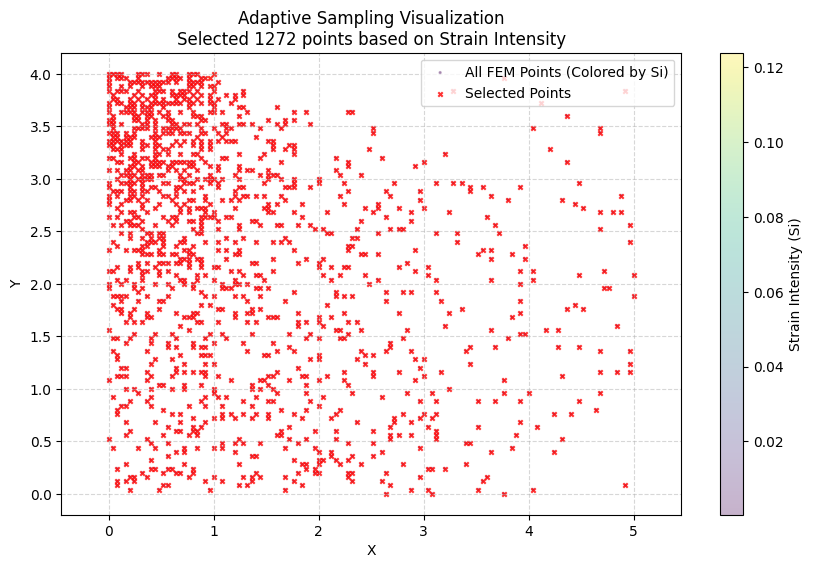


Training Configuration:
Total Epochs:             60000
Collocation Points:       1272 (Stress-based sampling)
Boundary Points:          4000
Young's Modulus (E):      15.0
Poisson's Ratio (ν):      0.3
Yield Stress (σ_y):       0.07



Training:   0%|                              | 0/60000 [00:00<?, ?it/s]/tmp/ipykernel_1828/1785753598.py:139: UserWarning: Using a target size (torch.Size([1272, 1])) that is different to the input size (torch.Size([1272, 1272])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  L_plane_strain = F.mse_loss(d_epsilon_e_zz + d_epsilon_p_zz, torch.zeros_like(d_epsilon_e_zz))
Training:   8%|██▌                           | 5005/60000 [01:43<18:33, 49.40it/s, Loss=0.003193, PDE=0.000898, BC=0.000486, Data=0.000090]


EPOCH 5000/60000
  Total Loss:         0.0031053284
  BC Loss:            0.0005034024
  PDE Total:          0.0007861427
    → Equilibrium:    0.0000532003
    → Constitutive:   0.0004862761
    → Yield:          0.0002459293
    → Plane Strain:   0.0000007371
  Data Loss:          0.0000907892



Training:  17%|█████                         | 10003/60000 [03:22<17:26, 47.79it/s, Loss=0.002149, PDE=0.000710, BC=0.000509, Data=0.000046]


EPOCH 10000/60000
  Total Loss:         0.0022616372
  BC Loss:            0.0005458401
  PDE Total:          0.0007229110
    → Equilibrium:    0.0000605685
    → Constitutive:   0.0003897723
    → Yield:          0.0002717106
    → Plane Strain:   0.0000008596
  Data Loss:          0.0000496443



...


EPOCH 50000/60000
  Total Loss:         0.0012653642
  BC Loss:            0.0003251150
  PDE Total:          0.0006398814
    → Equilibrium:    0.0000925369
    → Constitutive:   0.0002402638
    → Yield:          0.0003057732
    → Plane Strain:   0.0000013075
  Data Loss:          0.0000150184



Training:  92%|███████████████████████████▌  | 55006/60000 [18:00<01:42, 48.55it/s, Loss=0.001258, PDE=0.000638, BC=0.000318, Data=0.000015]


EPOCH 55000/60000
  Total Loss:         0.0012572162
  BC Loss:            0.0003204250
  PDE Total:          0.0006389078
    → Equilibrium:    0.0000905761
    → Constitutive:   0.0002391208
    → Yield:          0.0003078957
    → Plane Strain:   0.0000013152
  Data Loss:          0.0000148942



Training: 100%|██████████████████████████████| 60000/60000 [19:39<00:00, 50.87it/s, Loss=0.001256, PDE=0.000643, BC=0.000314, Data=0.000015]
/tmp/ipykernel_1828/3947754294.py:267: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  temp_scheduler.step()



EPOCH 60000/60000
  Total Loss:         0.0012562585
  BC Loss:            0.0003140994
  PDE Total:          0.0006432569
    → Equilibrium:    0.0000890365
    → Constitutive:   0.0002455766
    → Yield:          0.0003073427
    → Plane Strain:   0.0000013011
  Data Loss:          0.0000149451


🎉 TRAINING COMPLETED SUCCESSFULLY! 🎉
Total Epochs:         60000
Collocation Points:   1272 (Stress-based adaptive sampling)
Final Loss:           0.0012562585
Final BC Loss:        0.0003140994
Final PDE Loss:       0.0006432569
  → Equilibrium:      0.0000890365
  → Constitutive:     0.0002455766
  → Yield:            0.0003073427
  → Plane Strain:     0.0000013011
Final Data Loss:      0.0000149451

Creating training history plots...
✓ Training history plot saved: 'loss_history_vonmises_adaptive.png'

✓ Training completed for Von-Mises Plasticity
✓ Used stress-based adaptive sampling: 1272 collocation points
✓ Final total loss: 0.0012562585


✅ Training Completed Successfully!

📊 Generat

In [ ]:
if __name__ == "__main__":
    
    print("\n" + "="*70)
    print("🔧 Using Material Properties from previous cell")
    print("="*70)
    print(f"Young's modulus (E):  {E:,.1f} kPa")
    print(f"Poisson's ratio (ν):  {nu}")
    print(f"Yield stress (σ_y):   {sigma_y:,.2f} kPa")
    print("="*70)
    

    
    xy_disp_data = fem_xy
    u_data = fem_ux
    v_data = fem_uy
    
    xy_stress_data = fem_xy
    s_xx_data = fem_stress_xx
    s_yy_data = fem_stress_yy
    s_xy_data = fem_stress_xy
    s_zz_data = fem_stress_zz
    
    xy_strain_data = fem_xy
    e_xx_data = fem_strain_xx
    e_yy_data = fem_strain_yy
    e_xy_data = fem_strain_xy
    
    print(f"\n✅ Using {len(xy_disp_data)} FEM data points")
    print(f"   - Displacement points: {len(xy_disp_data)}")
    print(f"   - Stress points:       {len(xy_stress_data)}")
    print(f"   - Strain points:       {len(xy_strain_data)}\n")
    
    # Initialize network
    net = Net().to(device)
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    print("="*70)
    print("🚀 Starting Training with Adaptive Sampling")
    print("="*70)
    
    # ✅ Train with strain data
    trained_net, metrics = train_with_adaptive_sampling(
        net=net,
        optimizer=optimizer,
        n_epochs=60000,
        E=E, nu=nu, sigma_y=sigma_y,
        xy_disp_data=xy_disp_data, u_data=u_data, v_data=v_data,
        xy_stress_data=xy_stress_data, s_xx_data=s_xx_data, 
        s_yy_data=s_yy_data, s_xy_data=s_xy_data, s_zz_data=s_zz_data,
        xy_strain_data=xy_strain_data, e_xx_data=e_xx_data,
        e_yy_data=e_yy_data, e_xy_data=e_xy_data,
        device=device,
    )
    
    print("\n" + "="*70)
    print("✅ Training Completed Successfully!")
    print("="*70)
    
    # Plot results
    print("\n" + "="*70)
    print("📊 Generating Results and Plots")
    print("="*70)
    
    try:
        df_results = plot_results(
            net=trained_net,
            E=E, nu=nu, sigma_y=sigma_y,
            device=device,
            output_filename='Footing_data_Von-mises_autodiff.csv'
        )
        print("\n" + "="*70)
        print("✅ All tasks completed successfully!")
        print("="*70)
        print(f"\n📁 Output file: Footing_data_Von-mises_autodiff.csv")
        print(f"📊 Total points saved: {len(df_results):,}")
    except Exception as e:
        print("\n" + "="*70)
        print("❌ Error in plot_results")
        print("="*70)
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()